






# Diabetes 130-US Hospitals Exploratory Data Analysis

## Project Context

This notebook explores the Diabetes 130-US Hospitals dataset as the clinical-data component of the **Integrated Intelligent Health Monitoring and Clinical Decision Support System**.

The goals are to inspect dataset structure and quality, understand the readmission target, evaluate missingness and categorical variables, identify candidate predictors, examine class imbalance, visualize important patterns, and document decisions that will guide later preprocessing and modeling.

The Diabetes dataset is not joined directly to PAMAP2 because the datasets represent different populations. Their model outputs will be integrated later at the application and agent level.


## Setup

Import the libraries used for data inspection, analysis, and visualization. A fixed random seed is defined for reproducibility.


In [46]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42


## Data Location

The notebook expects the downloaded dataset at:

`data/raw/diabetes/diabetic_data.csv`

The code below detects whether the notebook is being run from the project root or from the `notebooks` directory.


In [47]:
cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from the "
        "healthcare_capstone repository or its notebooks directory."
    )

DATA_FILE = PROJECT_ROOT / "data" / "raw" / "diabetes" / "diabetic_data.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_FILE)
print("Dataset exists:", DATA_FILE.exists())


Project root: c:\Private\UDACITY\CAPSTONE\INTEGRATED_AI_SYSTEM\healthcare_capstone
Dataset path: c:\Private\UDACITY\CAPSTONE\INTEGRATED_AI_SYSTEM\healthcare_capstone\data\raw\diabetes\diabetic_data.csv
Dataset exists: True


## Load the Dataset

Load the clinical encounter data and confirm its dimensions before beginning exploratory analysis.


In [48]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_FILE}. "
        "Place diabetic_data.csv inside data/raw/diabetes/."
    )

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully.
Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Initial Dataset Inspection

Inspect the number of observations, feature names, data types, and duplicate rows. This establishes the basic structure of the dataset and highlights potential preprocessing requirements.


In [49]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumn names:")
for column in df.columns:
    print(column)


Number of rows: 101,766
Number of columns: 50

Column names:
encounter_id
patient_nbr
race
gender
age
weight
admission_type_id
discharge_disposition_id
admission_source_id
time_in_hospital
payer_code
medical_specialty
num_lab_procedures
num_procedures
num_medications
number_outpatient
number_emergency
number_inpatient
diag_1
diag_2
diag_3
number_diagnoses
max_glu_serum
A1Cresult
metformin
repaglinide
nateglinide
chlorpropamide
glimepiride
acetohexamide
glipizide
glyburide
tolbutamide
pioglitazone
rosiglitazone
acarbose
miglitol
troglitazone
tolazamide
examide
citoglipton
insulin
glyburide-metformin
glipizide-metformin
glimepiride-pioglitazone
metformin-rosiglitazone
metformin-pioglitazone
change
diabetesMed
readmitted


In [50]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [51]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print(f"Percentage of duplicates: {duplicate_count / len(df) * 100:.2f}%")


Number of duplicate rows: 0
Percentage of duplicates: 0.00%


## Descriptive Statistics

Review numerical and categorical summaries separately. Numerical summaries help identify ranges and unusual values, while categorical summaries reveal cardinality and dominant categories.


In [52]:
numeric_summary = df.select_dtypes(include=np.number).describe().T
numeric_summary


,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


In [53]:
categorical_columns = df.select_dtypes(include=["object", "str"]).columns

categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_columns].nunique(),
    "most_frequent": [
        df[col].mode().iloc[0] if not df[col].mode().empty else np.nan
        for col in categorical_columns
    ]
})

categorical_summary


,unique_values,most_frequent
race,6,Caucasian
gender,3,Female
age,10,[70-80)
weight,10,?
payer_code,18,?
medical_specialty,73,?
diag_1,717,428
diag_2,749,276
diag_3,790,250
max_glu_serum,3,Norm


## Missing-Value Analysis

The dataset uses the string `?` for some unavailable values. These entries must be counted explicitly in addition to standard `NaN` values so later preprocessing decisions are based on the true amount of missing information.


In [54]:
question_mark_counts = (df == "?").sum()
question_mark_counts = question_mark_counts[
    question_mark_counts > 0
].sort_values(ascending=False)

question_mark_counts


weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [55]:
missing_report = pd.DataFrame({
    "question_mark_count": (df == "?").sum(),
    "nan_count": df.isna().sum()
})

missing_report["total_missing"] = (
    missing_report["question_mark_count"] +
    missing_report["nan_count"]
)

missing_report["missing_percent"] = (
    missing_report["total_missing"] / len(df) * 100
)

missing_report = missing_report[
    missing_report["total_missing"] > 0
].sort_values("missing_percent", ascending=False)

missing_report


,question_mark_count,nan_count,total_missing,missing_percent
weight,98569,0,98569,96.858479
max_glu_serum,0,96420,96420,94.746772
A1Cresult,0,84748,84748,83.277322
medical_specialty,49949,0,49949,49.082208
payer_code,40256,0,40256,39.557416
race,2273,0,2273,2.233555
diag_3,1423,0,1423,1.398306
diag_2,358,0,358,0.351787
diag_1,21,0,21,0.020636


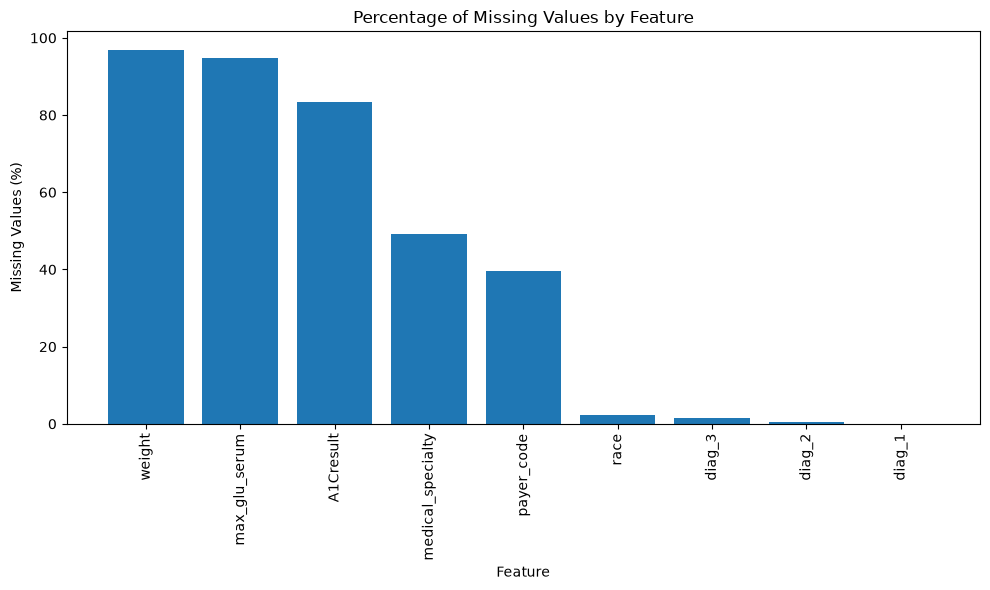

In [56]:
plt.figure(figsize=(10, 6))
plt.bar(missing_report.index, missing_report["missing_percent"])
plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## Readmission Target Analysis

The original `readmitted` variable contains three categories:

- `<30` — readmission occurred within 30 days;
- `>30` — readmission occurred after more than 30 days;
- `NO` — no recorded readmission.

For the clinical prediction component, the primary target will be a binary indicator of whether readmission occurred within 30 days. The binary target is created here only for exploratory analysis. The reusable transformation will later be implemented in the production preprocessing module.


In [57]:
readmission_counts = df["readmitted"].value_counts()
readmission_percentages = df["readmitted"].value_counts(normalize=True) * 100

readmission_distribution = pd.DataFrame({
    "count": readmission_counts,
    "percentage": readmission_percentages
})

readmission_distribution


,count,percentage
readmitted,,
NO,54864,53.911916
>30,35545,34.928169
<30,11357,11.159916


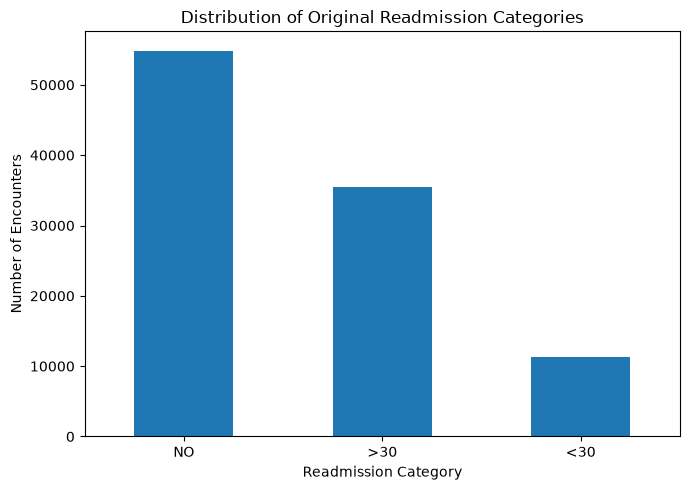

In [58]:
plt.figure(figsize=(7, 5))
df["readmitted"].value_counts().plot(kind="bar")
plt.title("Distribution of Original Readmission Categories")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [59]:
df_eda = df.copy()
df_eda["readmitted_30"] = (df_eda["readmitted"] == "<30").astype(int)

binary_distribution = df_eda["readmitted_30"].value_counts(normalize=True) * 100

print("Binary target distribution (%):")
print(binary_distribution.round(2))


Binary target distribution (%):
readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64


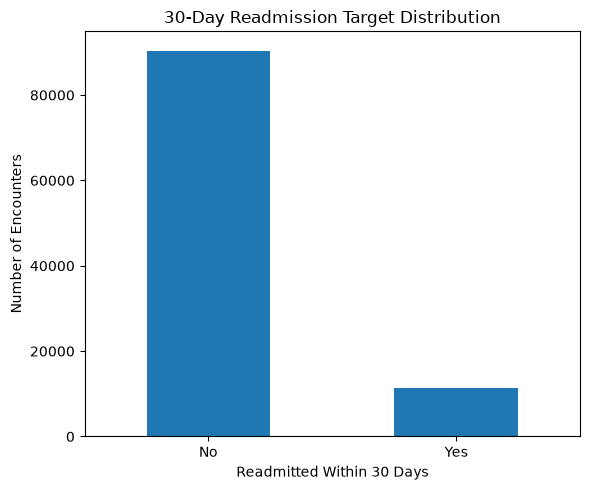

In [60]:
plt.figure(figsize=(6, 5))
df_eda["readmitted_30"].value_counts().sort_index().plot(kind="bar")
plt.title("30-Day Readmission Target Distribution")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Number of Encounters")
plt.xticks(ticks=[0, 1], labels=["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()


## Demographic Patterns

Age is examined as a descriptive variable to understand whether readmission rates differ across age groups. These patterns are exploratory and should not be interpreted as causal.


In [61]:
age_counts = df_eda["age"].value_counts().sort_index()
age_counts


age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

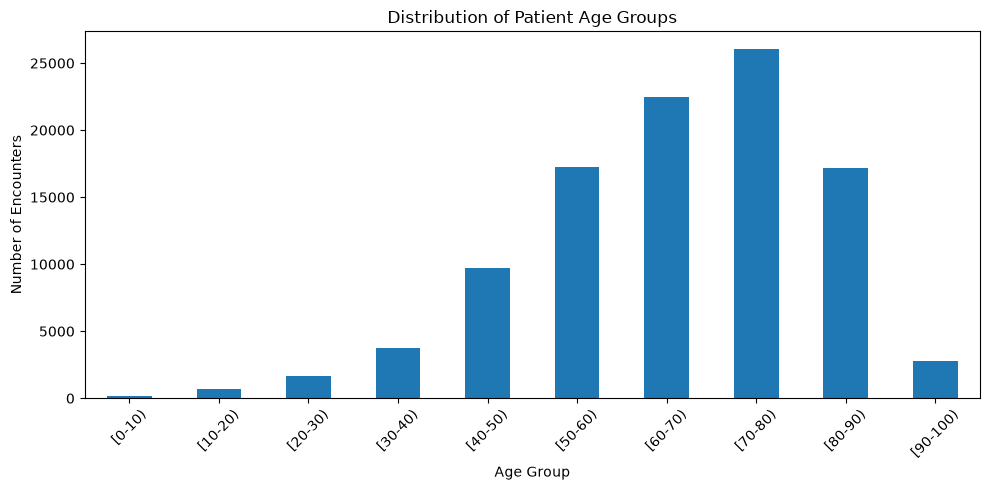

In [62]:
plt.figure(figsize=(10, 5))
age_counts.plot(kind="bar")
plt.title("Distribution of Patient Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [63]:
readmission_by_age = (
    df_eda.groupby("age")["readmitted_30"]
    .mean()
    .sort_index()
    * 100
)

readmission_by_age


age
[0-10)       1.863354
[10-20)      5.788712
[20-30)     14.242607
[30-40)     11.231788
[40-50)     10.604027
[50-60)      9.666203
[60-70)     11.128408
[70-80)     11.773055
[80-90)     12.083503
[90-100)    11.099177
Name: readmitted_30, dtype: float64

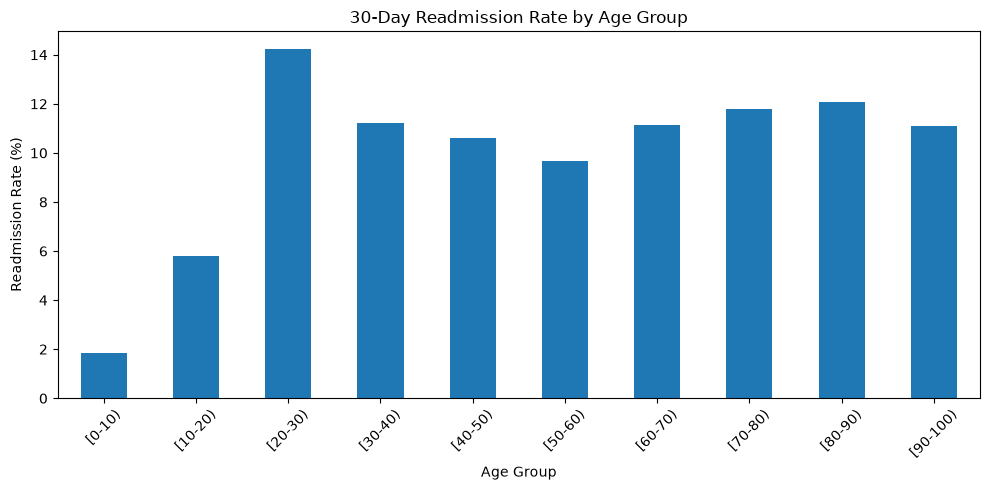

In [64]:
plt.figure(figsize=(10, 5))
readmission_by_age.plot(kind="bar")
plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Healthcare Utilization and Clinical Workload Features

Several numerical variables describe the intensity of the hospital encounter and previous healthcare utilization. These variables are important candidates for the readmission model.


In [65]:
candidate_numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

df_eda[candidate_numeric_features].describe().T


,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


In [66]:
readmission_numeric_summary = (
    df_eda.groupby("readmitted_30")[candidate_numeric_features]
    .mean()
    .T
)

readmission_numeric_summary.columns = [
    "Not Readmitted <30",
    "Readmitted <30"
]

readmission_numeric_summary


,Not Readmitted <30,Readmitted <30
time_in_hospital,4.349224,4.768249
num_lab_procedures,42.953644,44.226028
num_procedures,1.347123,1.280884
num_medications,15.911137,16.903143
number_outpatient,0.360871,0.436911
number_emergency,0.177803,0.357313
number_inpatient,0.561648,1.224003
number_diagnoses,7.388667,7.692789


### Previous Inpatient Utilization

Prior inpatient encounters may be informative for future readmission risk. The raw distribution and grouped readmission rates are examined below.


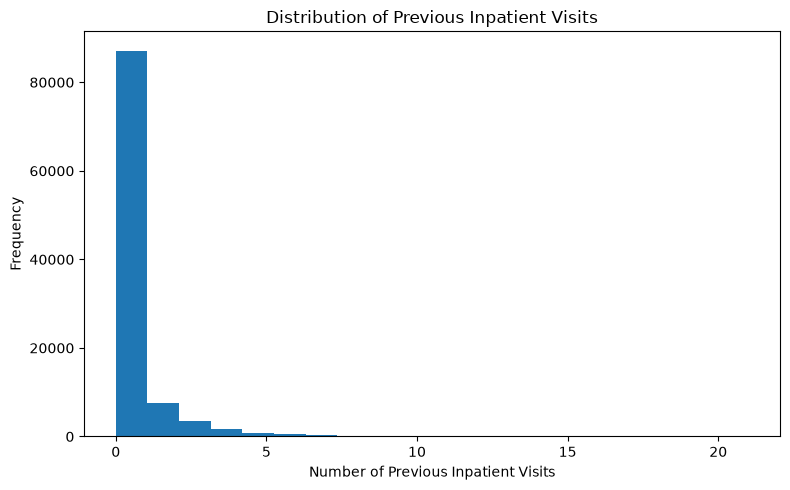

In [67]:
plt.figure(figsize=(8, 5))
plt.hist(df_eda["number_inpatient"], bins=20)
plt.title("Distribution of Previous Inpatient Visits")
plt.xlabel("Number of Previous Inpatient Visits")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [68]:
df_eda["inpatient_visit_group"] = pd.cut(
    df_eda["number_inpatient"],
    bins=[-1, 0, 1, 2, 3, 5, np.inf],
    labels=["0", "1", "2", "3", "4-5", "6+"]
)

readmission_by_inpatient = (
    df_eda.groupby("inpatient_visit_group", observed=False)["readmitted_30"]
    .mean()
    * 100
)

readmission_by_inpatient


inpatient_visit_group
0       8.437084
1      12.924543
2      17.433254
3      20.287306
4-5    26.211997
6+     39.784053
Name: readmitted_30, dtype: float64

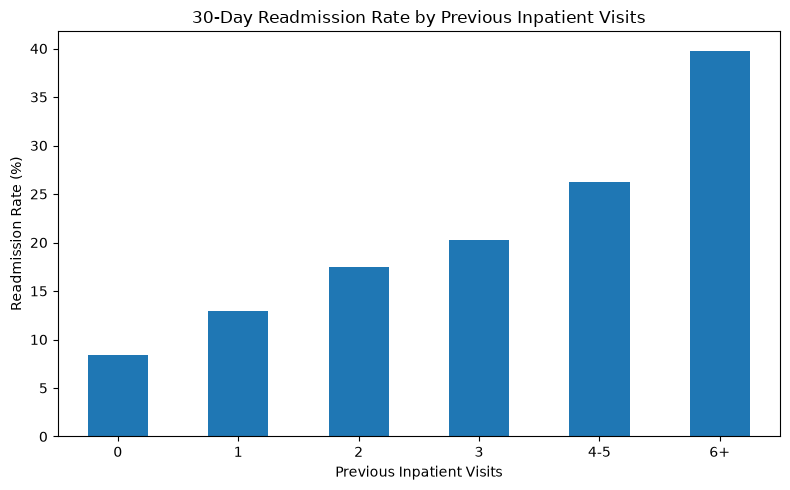

In [69]:
plt.figure(figsize=(8, 5))
readmission_by_inpatient.plot(kind="bar")
plt.title("30-Day Readmission Rate by Previous Inpatient Visits")
plt.xlabel("Previous Inpatient Visits")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Medication Burden

The number of medications may reflect encounter complexity. The distributions for encounters with and without 30-day readmission are compared below.


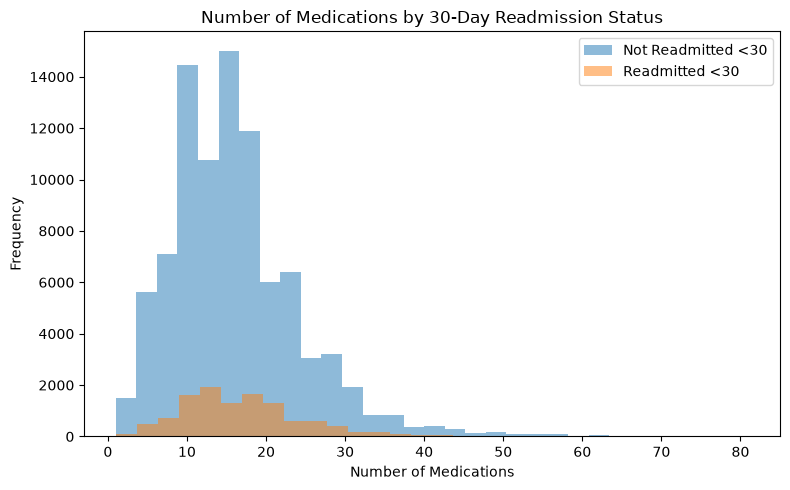

In [70]:
plt.figure(figsize=(8, 5))

not_readmitted = df_eda.loc[
    df_eda["readmitted_30"] == 0,
    "num_medications"
]

readmitted = df_eda.loc[
    df_eda["readmitted_30"] == 1,
    "num_medications"
]

plt.hist(not_readmitted, bins=30, alpha=0.5, label="Not Readmitted <30")
plt.hist(readmitted, bins=30, alpha=0.5, label="Readmitted <30")

plt.title("Number of Medications by 30-Day Readmission Status")
plt.xlabel("Number of Medications")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


## Selected Categorical and Clinical Variables

Inspect demographic categories, diagnosis codes, laboratory results, and diabetes-treatment indicators. High-cardinality variables will require deliberate preprocessing rather than automatic one-hot encoding of every raw value.


In [71]:
pd.crosstab(
    df_eda["gender"],
    df_eda["readmitted_30"],
    normalize="index"
).round(3)


readmitted_30,0,1
gender,,
Female,0.888,0.112
Male,0.889,0.111
Unknown/Invalid,1.000,0.000


In [72]:
df_eda["race"].value_counts(dropna=False)


race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [73]:
diagnosis_columns = ["diag_1", "diag_2", "diag_3"]

for column in diagnosis_columns:
    print(f"\n{column}")
    print(df_eda[column].value_counts().head(15))



diag_1
diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
Name: count, dtype: int64

diag_2
diag_2
276       6752
428       6662
250       6071
427       5036
401       3736
496       3305
599       3288
403       2823
414       2650
411       2566
250.02    2074
707       1999
585       1871
584       1649
491       1545
Name: count, dtype: int64

diag_3
diag_3
250       11555
401        8289
276        5175
428        4577
427        3955
414        3664
496        2605
403        2357
585        1992
272        1969
599        1941
?          1423
V45        1389
250.02     1369
707        1360
Name: count, dtype: int64


In [74]:
for column in ["max_glu_serum", "A1Cresult"]:
    print(f"\n{column}")
    print(df_eda[column].value_counts(dropna=False))



max_glu_serum
max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

A1Cresult
A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64


In [75]:
for column in ["insulin", "change", "diabetesMed"]:
    print(f"\n{column}")
    print(df_eda[column].value_counts(dropna=False))



insulin
insulin
No        47383
Steady    30849
Down      12218
Up        11316
Name: count, dtype: int64

change
change
No    54755
Ch    47011
Name: count, dtype: int64

diabetesMed
diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64


## Patient Identifiers and Repeated Encounters

`encounter_id` and `patient_nbr` are identifiers rather than ordinary clinical predictors. Repeated encounters matter because allowing records for the same patient to appear in both training and testing data can produce an overly optimistic evaluation.

The final modeling workflow will use this information when choosing a train/test strategy.


In [76]:
identifier_columns = ["encounter_id", "patient_nbr"]
df_eda[identifier_columns].head()


,encounter_id,patient_nbr
0,2278392,8222157
1,149190,55629189
2,64410,86047875
3,500364,82442376
4,16680,42519267


In [77]:
encounters_per_patient = (
    df_eda.groupby("patient_nbr")
    .size()
    .sort_values(ascending=False)
)

encounters_per_patient.describe()


count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
dtype: float64

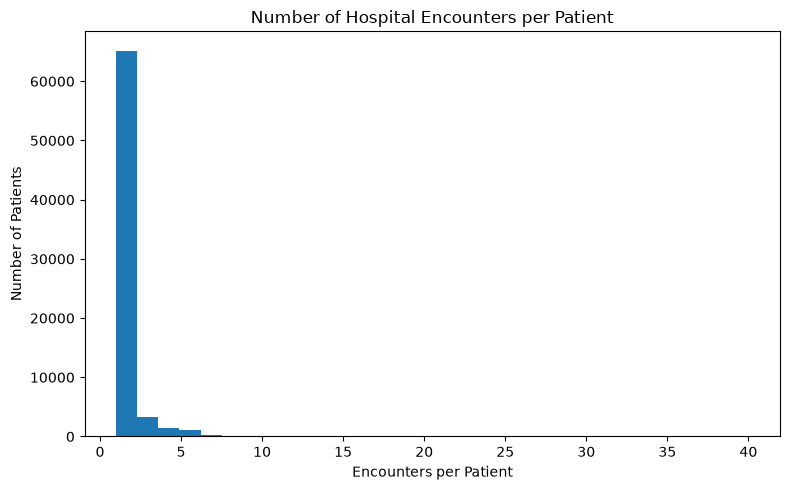

In [78]:
plt.figure(figsize=(8, 5))
plt.hist(encounters_per_patient, bins=30)
plt.title("Number of Hospital Encounters per Patient")
plt.xlabel("Encounters per Patient")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


## Correlation Analysis

A correlation matrix provides a compact view of linear relationships among selected numerical variables. Correlation is used here for exploratory analysis only and does not establish causation.


In [79]:
correlation_features = candidate_numeric_features + ["readmitted_30"]
correlation_matrix = df_eda[correlation_features].corr()
correlation_matrix.round(3)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_30
time_in_hospital,1.000,0.318,0.191,0.466,-0.009,-0.010,0.074,0.220,0.044
num_lab_procedures,0.318,1.000,0.058,0.268,-0.008,-0.002,0.039,0.153,0.020
num_procedures,0.191,0.058,1.000,0.386,-0.025,-0.038,-0.066,0.074,-0.012
num_medications,0.466,0.268,0.386,1.000,0.045,0.013,0.064,0.262,0.038
number_outpatient,-0.009,-0.008,-0.025,0.045,1.000,0.091,0.107,0.094,0.019
number_emergency,-0.010,-0.002,-0.038,0.013,0.091,1.000,0.267,0.056,0.061
number_inpatient,0.074,0.039,-0.066,0.064,0.107,0.267,1.000,0.105,0.165
number_diagnoses,0.220,0.153,0.074,0.262,0.094,0.056,0.105,1.000,0.050
readmitted_30,0.044,0.020,-0.012,0.038,0.019,0.061,0.165,0.050,1.000


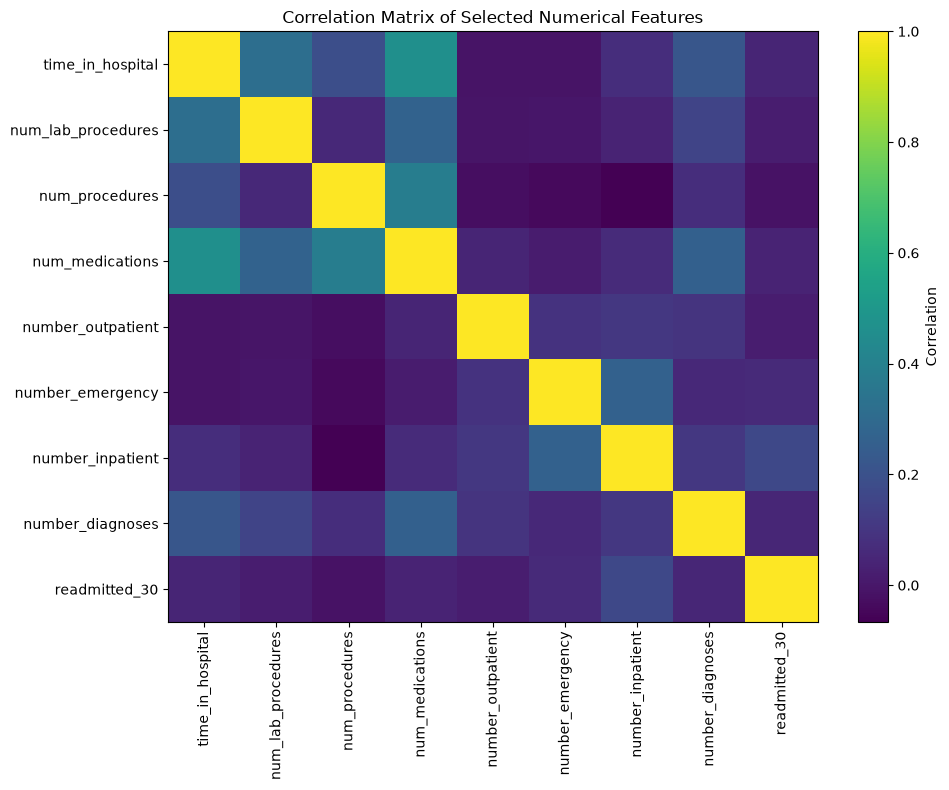

In [80]:
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix of Selected Numerical Features")
plt.tight_layout()
plt.show()


## Candidate Features and Modeling Considerations

The following variables are retained as initial candidates for the readmission model. This is an exploratory list rather than the final production feature set.

The preprocessing stage will determine which variables should be retained, removed, grouped, or encoded based on missingness, cardinality, leakage risk, and interpretability.


In [81]:
candidate_features = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "medical_specialty",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "diag_1",
    "diag_2",
    "diag_3",
    "number_diagnoses",
    "max_glu_serum",
    "A1Cresult",
    "insulin",
    "change",
    "diabetesMed"
]

candidate_features


['race',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'insulin',
 'change',
 'diabetesMed']

### High Missingness

Features with substantial missing data require special consideration. The threshold below is used only to flag variables for review; it does not automatically remove them.


In [82]:
HIGH_MISSING_THRESHOLD = 40

high_missing_columns = (
    missing_report.loc[
        missing_report["missing_percent"] > HIGH_MISSING_THRESHOLD
    ]
    .index
    .tolist()
)

print(
    f"Columns with more than {HIGH_MISSING_THRESHOLD}% missing values:"
)
print(high_missing_columns)


Columns with more than 40% missing values:
['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty']


### Categorical Cardinality

High-cardinality categorical features can create very large encoded feature spaces. Their cardinality is inspected before deciding whether values should be grouped or transformed.


In [83]:
cardinality_report = (
    df_eda[categorical_columns]
    .nunique()
    .sort_values(ascending=False)
    .to_frame("unique_values")
)

cardinality_report


,unique_values
diag_3,790
diag_2,749
diag_1,717
medical_specialty,73
payer_code,18
age,10
weight,10
race,6
glyburide-metformin,4
repaglinide,4


## Data Quality Summary

Create a compact summary of the most important dataset characteristics discovered during exploratory analysis.


In [84]:
summary = {
    "rows": len(df_eda),
    "columns": df.shape[1],
    "duplicate_rows": int(df.duplicated().sum()),
    "positive_readmission_cases": int(df_eda["readmitted_30"].sum()),
    "positive_readmission_rate_percent": round(
        df_eda["readmitted_30"].mean() * 100,
        2
    ),
    "unique_patients": int(df_eda["patient_nbr"].nunique()),
    "features_with_missing_values": int(len(missing_report))
}

summary


{'rows': 101766,
 'columns': 50,
 'duplicate_rows': 0,
 'positive_readmission_cases': 11357,
 'positive_readmission_rate_percent': np.float64(11.16),
 'unique_patients': 71518,
 'features_with_missing_values': 9}

## Exploratory Analysis Summary

The Diabetes 130-US Hospitals dataset provides a large collection of clinical encounters containing demographic, healthcare-utilization, diagnosis, laboratory, and medication-related information.

The exploratory analysis is intended to establish several modeling considerations:

- **Target imbalance:** 30-day readmissions form the positive class and may be substantially less common than negative cases. Model evaluation should therefore emphasize recall, precision, F1 score, and ROC-AUC rather than relying only on accuracy.
- **Missing data:** unavailable values represented by `?` require explicit handling, and high-missingness variables should be reviewed before inclusion.
- **Healthcare utilization:** previous inpatient, outpatient, and emergency encounters are important candidate predictors for later modeling.
- **Repeated patients:** some patients have multiple encounters, creating a potential source of train/test leakage if patient records are split across both sets.
- **Diagnosis complexity:** raw diagnosis variables have high categorical cardinality and should be transformed into more manageable groups before modeling.
- **Identifiers:** `encounter_id` and `patient_nbr` should not be treated as ordinary predictive features.

The actual outputs from this notebook should be used to refine these observations before they are quoted in the final report.


## Save Exploratory Reports

Save small analysis summaries for later reference. The cleaned modeling dataset is intentionally **not** created here; reusable preprocessing will be implemented in the production source module.


In [85]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "diabetes"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

missing_report.to_csv(
    OUTPUT_DIR / "eda_missing_values.csv"
)

readmission_distribution.to_csv(
    OUTPUT_DIR / "eda_readmission_distribution.csv"
)

pd.DataFrame([summary]).to_csv(
    OUTPUT_DIR / "eda_dataset_summary.csv",
    index=False
)

print("EDA summary files saved to:", OUTPUT_DIR)


EDA summary files saved to: c:\Private\UDACITY\CAPSTONE\INTEGRATED_AI_SYSTEM\healthcare_capstone\data\processed\diabetes


Verify the class imbalance and repeated-patient structure before proceeding with the implementation step for production preprocessing `src/preprocessing/diabetes.py`.

That module will convert the exploratory findings from this notebook into a reproducible preprocessing workflow for the readmission model, including target creation, missing-value handling, identifier removal, diagnosis grouping, categorical encoding, and leakage-aware dataset preparation.


In [86]:
df.shape

df["readmitted"].value_counts()

binary_distribution

missing_report.head(10)

encounters_per_patient.describe()

count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
dtype: float64

Analysis of encounter frequency demonstrated that the Diabetes 130-US Hospitals dataset contains repeated observations for many patients. Although most patients appeared only once, some individuals were associated with multiple hospital encounters. This observation is important because distributing encounters from the same patient across both training and testing datasets could artificially inflate model performance. Consequently, patient identifiers will be treated carefully during preprocessing.

In [87]:
df.shape

df["readmitted"].value_counts()

binary_distribution

missing_report.head(10)

,question_mark_count,nan_count,total_missing,missing_percent
weight,98569,0,98569,96.858479
max_glu_serum,0,96420,96420,94.746772
A1Cresult,0,84748,84748,83.277322
medical_specialty,49949,0,49949,49.082208
payer_code,40256,0,40256,39.557416
race,2273,0,2273,2.233555
diag_3,1423,0,1423,1.398306
diag_2,358,0,358,0.351787
diag_1,21,0,21,0.020636
